#**Alwande Lwazi Ntuli**
#**22432331**
#**Technical Programming 2 Final Exam**

# 2026 South African Local Government Elections Analytics
## Integrated Election Forecasting Solution — City of Cape Town (CPT)

**Examination date (analysis context):** 05 October 2026  
**Election Day (prediction target):** 04 November 2026  
**Role:** Junior Data Architect and Machine Learning Engineer  
**Selected metropolitan municipality:** City of Cape Town (CPT), Western Cape  

---

### 1. Problem definition

The 2026 South African Local Government Elections will take place on **04 November 2026**. This notebook develops an **evidence-based, technically defensible** predictive solution for **one** metropolitan municipality using only **publicly available information on or before 05 October 2026**.

This work is **not** a political opinion and must **not** be read as advice on who should govern. The aim is to test whether historical election results and relevant supporting open data can be transformed into a coherent machine-learning solution with transparent data quality, modelling choices, validation, and interpretation.

**Assessment priority:** quality of data, modelling decisions, evaluation, and interpretation is more important than any single forecast outcome.

---

### 2. Why City of Cape Town (CPT)?

CPT is selected because:

1. Official **IEC** local government election results are available at **ward** and **municipal** level for multiple years (including 2011, 2016, and 2021).  
2. Matching **voter turnout / registered voter** reports exist for the same municipality.  
3. Reputable **supporting open data** (e.g. Stats SA Census 2022 municipal indicators; City of Cape Town ward attributes) can be linked for feature enrichment.  
4. Ward identifiers and multi-year history allow a **defensive geographic alignment** strategy before ward-level comparison or prediction.

All datasets used are from **credible, traceable** open sources. Direct source links are recorded in the Data Collection section and in `SOURCES.txt`.

---

### 3. Analytical questions (model outputs for 04 November 2026)

The solution estimates the following **selected outcomes** for CPT:

1. **Metro-level lead:** which relevant party is projected to receive the **largest aggregate vote total or vote share** in CPT; and whether **coalition formations** appear analytically plausible from seat/vote patterns.  
   - These are **model outputs only**. They are **not** interpreted as a prediction of who will govern the municipality.  
2. **Ward-level lead:** which relevant party is projected to **lead in each of three selected wards**, with justification for ward selection and geographically defensive historical comparisons.  
3. **Party estimates:** projected **vote total and/or vote share** for each relevant party included in the model.  
4. **Turnout:** projected **voter turnout** for CPT as an estimated number of votes and, where supported by the data, an appropriate turnout rate.

Independent candidates are included **only if** the available data support their inclusion.

---

### 4. Output labelling convention (mandatory)

Every result in this notebook is labelled as one of:

| Label | Meaning |
|--------|---------|
| **(1) Historical observation** | Values taken directly from official/published sources |
| **(2) Derived estimate** | Variables calculated from historical data (e.g. vote share, lags, rates) |
| **(3) Prediction (04 Nov 2026)** | Model estimate for Election Day, with assumptions, uncertainty, and limitations |

Unsupported precision or certainty will be avoided. Where data are insufficient for a reliable prediction, that conclusion will be stated **explicitly** and justified technically.

---

### 5. Method overview (ML project life cycle)

This notebook follows the machine learning project life cycle:

1. Problem definition  
2. Data collection  
3. Data cleaning / preparation  
4. Exploratory data analysis (EDA)  
5. Feature engineering  
6. Model building  
7. Evaluation / validation  
8. Deployment (Streamlit dashboard)  
9. Monitoring notes  

Where different targets require different approaches (e.g. turnout vs party vote share vs ward leader), **more than one model** may be used, with technical justification for each choice.

---

### 6. Geographic comparability warning

Observations from different election years and geographic units are **not automatically comparable**. Ward boundaries and ward identifiers may change over time (e.g. CPT had **111** wards in 2011 vs **116** wards in 2016/2021). A **defensive alignment strategy** will be applied or clearly explained before ward-level historical comparison or prediction.

## 2. Data collection

**Metro:** City of Cape Town (CPT)  
**Rule:** only public data available on or before 05 October 2026. No fictional data.

### Datasets used (related + mergeable)

| # | Dataset | Source | Link |
|---|---------|--------|------|
| 1 | LGE ward/metro party results (2011, 2016, 2021) | IEC | https://results.elections.org.za/home/Downloads/ME-Results |
| 2 | Voter turnout + registered voters by ward | IEC | https://results.elections.org.za/home/ |
| 3 | Census 2022 municipal indicators (CPT) | Stats SA | https://census.statssa.gov.za/ |

**Merge keys:** `ward_id`, `election_year`, `party_name`, municipality = `CPT`  

**Why relevant:** Dataset 1 supports party vote totals/shares and ward leaders. Dataset 2 supports turnout. Dataset 3 is supporting context for features.  

Full file-level URLs are listed in `SOURCES.txt` (uploaded with this project).

## 3. Importing the needed Libraries

In this cell I load the Python libraries needed for tables, charts, and machine learning.
Using Python 3 with open-source packages only (pandas, NumPy, Matplotlib, Seaborn, scikit-learn).

In [1]:
# Importing all libraries for data science and ML project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

# Chart style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

print("Libraries were loaded successfully")

Libraries loaded successfully


## 4. Upload the datasets

Upload the selected City of Cape Town CSV files into Google Colab.
These files come from IEC and Stats SA open sources (see Data collection / SOURCES.txt).

In [3]:
# Upload CSV files from: cpt-election-2026/data/raw
from google.colab import files

uploaded = files.upload()

print("Uploaded:")
for name in uploaded.keys():
    print("-", name)

Saving derived_iec_2011_cpt_voter_turnout_wards.csv to derived_iec_2011_cpt_voter_turnout_wards.csv
Saving derived_iec_2016_cpt_voter_turnout_wards.csv to derived_iec_2016_cpt_voter_turnout_wards.csv
Saving derived_iec_2021_cpt_voter_turnout_wards.csv to derived_iec_2021_cpt_voter_turnout_wards.csv
Saving openelections_2016_cpt_ward_party_votes.csv to openelections_2016_cpt_ward_party_votes.csv
Saving statssa_census2022_person_indicators_CPT.csv to statssa_census2022_person_indicators_CPT.csv
Uploaded:
- derived_iec_2011_cpt_voter_turnout_wards.csv
- derived_iec_2016_cpt_voter_turnout_wards.csv
- derived_iec_2021_cpt_voter_turnout_wards.csv
- openelections_2016_cpt_ward_party_votes.csv
- statssa_census2022_person_indicators_CPT.csv


## 5. Load the Datasets

Read the uploaded CSV files into pandas DataFrames so we can inspect and clean them.
Label reminder: these files are historical / supporting open data (not 2026 predictions).

In [4]:
# Load uploaded CSVs into DataFrames
turnout_2021 = pd.read_csv("derived_iec_2021_cpt_voter_turnout_wards.csv")
turnout_2016 = pd.read_csv("derived_iec_2016_cpt_voter_turnout_wards.csv")
turnout_2011 = pd.read_csv("derived_iec_2011_cpt_voter_turnout_wards.csv")

votes_2016 = pd.read_csv("openelections_2016_cpt_ward_party_votes.csv")
census_cpt = pd.read_csv("statssa_census2022_person_indicators_CPT.csv")

print("turnout_2021:", turnout_2021.shape)
print("turnout_2016:", turnout_2016.shape)
print("turnout_2011:", turnout_2011.shape)
print("votes_2016:", votes_2016.shape)
print("census_cpt:", census_cpt.shape)

turnout_2021: (116, 8)
turnout_2016: (116, 8)
turnout_2011: (111, 8)
votes_2016: (116, 38)
census_cpt: (1, 18)


## 6. Data understanding (first look)

Inspecting and analyzing each dataset: column names, first rows, data types, and missing values.
This is historical / supporting data only — not 2026 predictions.

In [5]:
# First look at each table
print("=== TURNOUT 2021 ===")
print(turnout_2021.columns.tolist())
display(turnout_2021.head())
print(turnout_2021.info())
print("Missing values:\n", turnout_2021.isna().sum())

print("\n=== VOTES 2016 ===")
print(votes_2016.columns.tolist())
display(votes_2016.head())
print(votes_2016.info())
print("Missing values:\n", votes_2016.isna().sum())

print("\n=== CENSUS CPT ===")
print(census_cpt.columns.tolist())
display(census_cpt.head())
print(census_cpt.info())
print("Missing values:\n", census_cpt.isna().sum())

=== TURNOUT 2021 ===
['election_year', 'municipality', 'ward_id', 'registered_voters', 'mec7_votes', 'voter_turnout_votes', 'voter_turnout_rate', 'label_type']


,election_year,municipality,ward_id,registered_voters,mec7_votes,voter_turnout_votes,voter_turnout_rate,label_type
0,2021,CPT,19100001,15635,0,10137,0.648353,derived_from_iec_xls
1,2021,CPT,19100002,20838,44,12747,0.610430,derived_from_iec_xls
2,2021,CPT,19100003,15898,3,9994,0.628514,derived_from_iec_xls
3,2021,CPT,19100004,15091,168,6748,0.442231,derived_from_iec_xls
4,2021,CPT,19100005,23528,0,14892,0.632948,derived_from_iec_xls


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   election_year        116 non-null    int64  
 1   municipality         116 non-null    object 
 2   ward_id              116 non-null    int64  
 3   registered_voters    116 non-null    int64  
 4   mec7_votes           116 non-null    int64  
 5   voter_turnout_votes  116 non-null    int64  
 6   voter_turnout_rate   116 non-null    float64
 7   label_type           116 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 7.4+ KB
None
Missing values:
 election_year          0
municipality           0
ward_id                0
registered_voters      0
mec7_votes             0
voter_turnout_votes    0
voter_turnout_rate     0
label_type             0
dtype: int64

=== VOTES 2016 ===
['constituency', 'da', 'anc', 'eff', 'acdp', 'aj', 'aic', 'vp', 'dip', 'udm', '

,constituency,da,anc,eff,acdp,aj,aic,vp,dip,udm,...,up,kr,sun,tg,pdm,ifp,sape,isp,pasa,independent
0,Ward 1,28797,736,211,424,51,17,343,59,14,...,16,0,1,3,6,4,0,2,0,0
1,Ward 2,25807,330,346,560,25,41,521,35,10,...,17,7,0,6,0,0,1,0,0,0
2,Ward 3,23205,414,173,237,3,10,457,49,9,...,12,0,0,1,1,7,0,0,0,0
3,Ward 4,11686,5317,776,151,20,114,61,17,42,...,6,0,0,2,0,2,0,1,1,0
4,Ward 5,26904,337,139,409,25,6,159,50,3,...,12,0,0,4,1,1,2,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 38 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   constituency  116 non-null    object
 1   da            116 non-null    int64 
 2   anc           116 non-null    int64 
 3   eff           116 non-null    int64 
 4   acdp          116 non-null    int64 
 5   aj            116 non-null    int64 
 6   aic           116 non-null    int64 
 7   vp            116 non-null    int64 
 8   dip           116 non-null    int64 
 9   udm           116 non-null    int64 
 10  cmc           116 non-null    int64 
 11  paca          116 non-null    int64 
 12  cotp          116 non-null    int64 
 13  pa            116 non-null    int64 
 14  npsa          116 non-null    int64 
 15  cp            116 non-null    int64 
 16  amp           116 non-null    int64 
 17  lpp           116 non-null    int64 
 18  asp           116 non-null    int64 
 19  apc     

,prov_code,dc_code,muni_code,name,area_km2,miif_category,government_transfers_subsidies_percent,male_pop_2011,female_pop_2011,total_pop_2011,school_attendance_ages_5_to_24_2011,sex_ratio_2011,male_pop_2022,female_pop_2022,total_pop_2022,school_attendance_ages_5_to_24_2022,sex_ratio_2022,growth_rate_2011_to_2022
0,WC,CPT,CPT,City of Cape Town,2440.6,METRO,15.3,1830701,1909330,3740031,788356,95.9,2307628,2465218,4772846,934103,93.6,2.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   prov_code                               1 non-null      object 
 1   dc_code                                 1 non-null      object 
 2   muni_code                               1 non-null      object 
 3   name                                    1 non-null      object 
 4   area_km2                                1 non-null      float64
 5   miif_category                           1 non-null      object 
 6   government_transfers_subsidies_percent  1 non-null      float64
 7   male_pop_2011                           1 non-null      int64  
 8   female_pop_2011                         1 non-null      int64  
 9   total_pop_2011                          1 non-null      int64  
 10  school_attendance_ages_5_to_24_2011     1 non-null      int64  
 1

## 7. Inspect turnout datasets (all years)

Check ward-level IEC voter turnout tables for 2011, 2016 and 2021.
These are historical observations (registered voters and turnout), not 2026 predictions.

In [6]:
# Combine turnout years for one view
turnout_all = pd.concat(
    [turnout_2011, turnout_2016, turnout_2021],
    ignore_index=True
)

print("Combined shape:", turnout_all.shape)
print("Columns:", turnout_all.columns.tolist())
print("\nYears:", sorted(turnout_all["election_year"].unique()))
print("Wards per year:")
print(turnout_all.groupby("election_year")["ward_id"].nunique())

display(turnout_all.head())
print("\nMissing values:")
print(turnout_all.isna().sum())
print("\nDuplicate rows:", turnout_all.duplicated().sum())

Combined shape: (343, 8)
Columns: ['election_year', 'municipality', 'ward_id', 'registered_voters', 'mec7_votes', 'voter_turnout_votes', 'voter_turnout_rate', 'label_type']

Years: [np.int64(2011), np.int64(2016), np.int64(2021)]
Wards per year:
election_year
2011    111
2016    116
2021    116
Name: ward_id, dtype: int64


,election_year,municipality,ward_id,registered_voters,mec7_votes,voter_turnout_votes,voter_turnout_rate,label_type
0,2011,CPT,19100001,16938,3,13099,0.773213,derived_from_iec_xls
1,2011,CPT,19100002,14268,31,10493,0.733828,derived_from_iec_xls
2,2011,CPT,19100003,17928,9,13241,0.738195,derived_from_iec_xls
3,2011,CPT,19100004,17676,0,11238,0.635777,derived_from_iec_xls
4,2011,CPT,19100005,15601,14,11806,0.756068,derived_from_iec_xls



Missing values:
election_year          0
municipality           0
ward_id                0
registered_voters      0
mec7_votes             0
voter_turnout_votes    0
voter_turnout_rate     0
label_type             0
dtype: int64

Duplicate rows: 0


## 8. Data cleaning — turnout

Turnout tables are already clean (I found no missing values, no duplicates).
We still standardise types and keep only comparable years for ward work (2016 and 2021 both have 116 wards).
2011 is kept for metro-level history only because ward counts differ (111 vs 116).

In [7]:
# Standardise turnout types
turnout_all["election_year"] = turnout_all["election_year"].astype(int)
turnout_all["ward_id"] = turnout_all["ward_id"].astype(str).str.strip()
turnout_all["municipality"] = turnout_all["municipality"].astype(str).str.strip()

# Ward-comparable years (defensive alignment)
turnout_ward = turnout_all[turnout_all["election_year"].isin([2016, 2021])].copy()

print("turnout_ward shape:", turnout_ward.shape)
print(turnout_ward.groupby("election_year")["ward_id"].nunique())
print("Missing after clean:", turnout_ward.isna().sum().sum())
display(turnout_ward.head())

turnout_ward shape: (232, 8)
election_year
2016    116
2021    116
Name: ward_id, dtype: int64
Missing after clean: 0


,election_year,municipality,ward_id,registered_voters,mec7_votes,voter_turnout_votes,voter_turnout_rate,label_type
111,2016,CPT,19100001,19398,23,15531,0.799701,derived_from_iec_xls
112,2016,CPT,19100002,18644,19,14120,0.756577,derived_from_iec_xls
113,2016,CPT,19100003,15858,19,12412,0.781760,derived_from_iec_xls
114,2016,CPT,19100004,15425,2,9265,0.600570,derived_from_iec_xls
115,2016,CPT,19100005,18014,10,14153,0.785231,derived_from_iec_xls


## 9. Inspect and clean party votes (2016)

`votes_2016` is ward × party vote counts (Open Elections / IEC-cited).
Historical observation. We clean names and create a `ward_id` that can merge with IEC turnout.

In [8]:
# First look
print("votes_2016 shape:", votes_2016.shape)
print(votes_2016.columns.tolist()[:10], "...")
display(votes_2016.head())
print("Missing values:", votes_2016.isna().sum().sum())
print("Duplicate rows:", votes_2016.duplicated().sum())

# Clean copy
votes_clean = votes_2016.copy()
votes_clean.columns = votes_clean.columns.str.strip().str.lower()

# constituency like "Ward 1" -> ward_id like "19100001"
votes_clean["ward_num"] = (
    votes_clean["constituency"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(int)
)
votes_clean["ward_id"] = votes_clean["ward_num"].apply(lambda x: f"1910{x:04d}")
votes_clean["election_year"] = 2016
votes_clean["municipality"] = "CPT"

print("\nAfter clean:")
display(votes_clean[["constituency", "ward_id", "da", "anc", "eff"]].head())
print("Wards:", votes_clean["ward_id"].nunique())

votes_2016 shape: (116, 38)
['constituency', 'da', 'anc', 'eff', 'acdp', 'aj', 'aic', 'vp', 'dip', 'udm'] ...


,constituency,da,anc,eff,acdp,aj,aic,vp,dip,udm,...,up,kr,sun,tg,pdm,ifp,sape,isp,pasa,independent
0,Ward 1,28797,736,211,424,51,17,343,59,14,...,16,0,1,3,6,4,0,2,0,0
1,Ward 2,25807,330,346,560,25,41,521,35,10,...,17,7,0,6,0,0,1,0,0,0
2,Ward 3,23205,414,173,237,3,10,457,49,9,...,12,0,0,1,1,7,0,0,0,0
3,Ward 4,11686,5317,776,151,20,114,61,17,42,...,6,0,0,2,0,2,0,1,1,0
4,Ward 5,26904,337,139,409,25,6,159,50,3,...,12,0,0,4,1,1,2,0,0,0


Missing values: 0
Duplicate rows: 0

After clean:


,constituency,ward_id,da,anc,eff
0,Ward 1,19100001,28797,736,211
1,Ward 2,19100002,25807,330,346
2,Ward 3,19100003,23205,414,173
3,Ward 4,19100004,11686,5317,776
4,Ward 5,19100005,26904,337,139


Wards: 116


## 10. Merge datasets

Merge 2016 ward turnout with 2016 ward party votes using `ward_id`.
This creates one analysis table for modelling and EDA.
Merged values are still based on historical observations; any new calculated fields will be labelled as derived.

In [9]:
# Use 2016 turnout only for this merge
turnout_2016_clean = turnout_ward[turnout_ward["election_year"] == 2016].copy()
turnout_2016_clean["ward_id"] = turnout_2016_clean["ward_id"].astype(str).str.strip()

# Merge on ward_id
merged_2016 = turnout_2016_clean.merge(
    votes_clean,
    on="ward_id",
    how="inner",
    suffixes=("_turnout", "_votes")
)

print("turnout_2016 wards:", turnout_2016_clean["ward_id"].nunique())
print("votes_clean wards:", votes_clean["ward_id"].nunique())
print("merged_2016 shape:", merged_2016.shape)
print("Missing values after merge:", merged_2016.isna().sum().sum())
display(merged_2016[["ward_id", "registered_voters", "voter_turnout_votes", "da", "anc", "eff"]].head())

turnout_2016 wards: 116
votes_clean wards: 116
merged_2016 shape: (116, 49)
Missing values after merge: 0


,ward_id,registered_voters,voter_turnout_votes,da,anc,eff
0,19100001,19398,15531,28797,736,211
1,19100002,18644,14120,25807,330,346
2,19100003,15858,12412,23205,414,173
3,19100004,15425,9265,11686,5317,776
4,19100005,18014,14153,26904,337,139


## 11. EDA — metro party support (2016)

**Chart type: bar chart**  
Reason: we compare total votes across party categories (not a time trend).

Method: sum each party's ward votes to get a metro-level total.
Label: derived from historical ward observations (not a 2026 prediction).

Metro party vote totals (2016) — derived from ward sums:
da             1664514
anc             608867
eff              79114
acdp             30285
independent       7077
dtype: int64


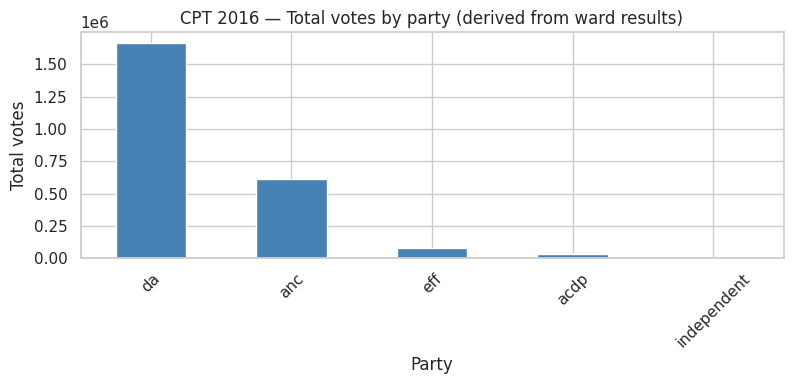

In [10]:
# Main parties to compare first
party_cols = ["da", "anc", "eff", "acdp", "independent"]

metro_totals = merged_2016[party_cols].sum().sort_values(ascending=False)

print("Metro party vote totals (2016) — derived from ward sums:")
print(metro_totals)

# Bar chart: compare categories
metro_totals.plot(kind="bar", color="steelblue")
plt.title("CPT 2016 — Total votes by party (derived from ward results)")
plt.xlabel("Party")
plt.ylabel("Total votes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. EDA — ward turnout distribution (2016)

**Chart type: histogram**  
Reason is turnout rate is one numeric variable; a histogram shows how it is spread across wards.

Label: historical observation (IEC-derived turnout rate), not a 2026 prediction.

In [ ]:
# Turnout rate across wards in the year (2016)
print(merged_2016["voter_turnout_rate"].describe())

plt.hist(merged_2016["voter_turnout_rate"], bins=15, color="teal", edgecolor="black")
plt.title("CPT 2016 — Distribution of ward voter turnout rate")
plt.xlabel("Voter turnout rate")
plt.ylabel("Number of wards")
plt.tight_layout()
plt.show()

count    116.000000
mean       0.640371
std        0.077704
min        0.497547
25%        0.576278
50%        0.633451
75%        0.690400
max        0.819867
Name: voter_turnout_rate, dtype: float64


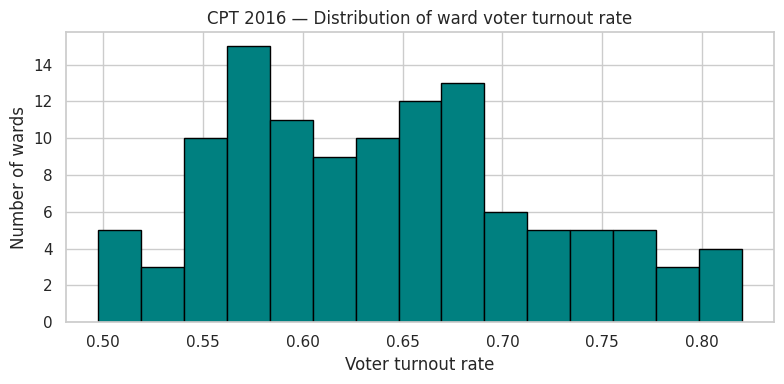

In [11]:
# Turnout rate across wards (2016)
print(merged_2016["voter_turnout_rate"].describe())

plt.hist(merged_2016["voter_turnout_rate"], bins=15, color="teal", edgecolor="black")
plt.title("CPT 2016 — Distribution of ward voter turnout rate")
plt.xlabel("Voter turnout rate")
plt.ylabel("Number of wards")
plt.tight_layout()
plt.show()

## 13. EDA — 2016 ward leaders

For each ward, find which party received the most votes.
**Chart type: bar chart**  
Reason: count how many wards each party led (category comparison).

Label: derived from historical 2016 ward votes (not a 2026 prediction).

Wards led by each party (2016):
ward_leader_2016
da     81
anc    35
Name: count, dtype: int64


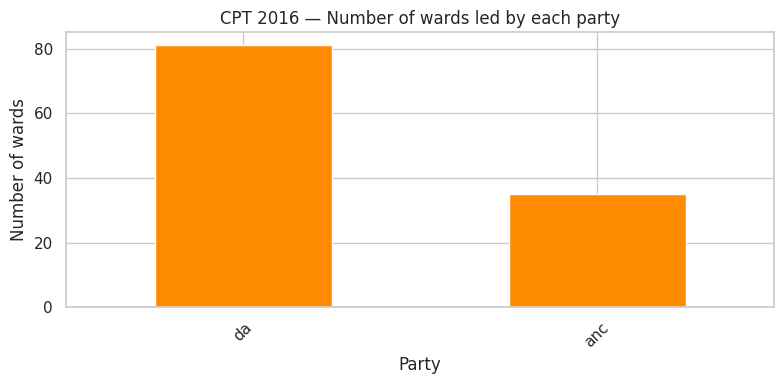

In [12]:
# Parties used to decide the ward leader
leader_parties = ["da", "anc", "eff", "acdp", "independent"]

# Party with highest votes in each ward
merged_2016["ward_leader_2016"] = merged_2016[leader_parties].idxmax(axis=1)

leader_counts = merged_2016["ward_leader_2016"].value_counts()
print("Wards led by each party (2016):")
print(leader_counts)

# Bar chart of ward-leader counts
leader_counts.plot(kind="bar", color="darkorange")
plt.title("CPT 2016 — Number of wards led by each party")
plt.xlabel("Party")
plt.ylabel("Number of wards")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Select three wards (justified)

Exam requirement: project the leading party in **three** wards.

**Selection rules (defensive):**
1. Ward IDs must exist in both 2016 and 2021 turnout data (116-ward system).
2. Choose contrasting political patterns so analysis is not one-sided:
   - one strong DA ward
   - one competitive ward (small gap between top 2)
   - one stronger ANC ward
3. We do **not** mix 2011 ward geography (111 wards) into these ward comparisons.

Label: ward choice is a methodological decision; 2016 leader is historical/derived.

In [13]:
# Only wards present in 2016 and 2021 turnout
wards_2016 = set(turnout_ward.loc[turnout_ward["election_year"] == 2016, "ward_id"])
wards_2021 = set(turnout_ward.loc[turnout_ward["election_year"] == 2021, "ward_id"])
common_wards = wards_2016 & wards_2021

df = merged_2016[merged_2016["ward_id"].isin(common_wards)].copy()
df["top_votes"] = df[leader_parties].max(axis=1)
df["second_votes"] = df[leader_parties].apply(lambda r: r.nlargest(2).iloc[1], axis=1)
df["lead_gap"] = df["top_votes"] - df["second_votes"]

# 1) Strong DA ward (largest DA share among DA-led wards)
da_wards = df[df["ward_leader_2016"] == "da"].copy()
da_wards["da_share"] = da_wards["da"] / da_wards[leader_parties].sum(axis=1)
ward_strong_da = da_wards.sort_values("da_share", ascending=False).iloc[0]["ward_id"]

# 2) Competitive ward (smallest lead gap)
ward_close = df.sort_values("lead_gap", ascending=True).iloc[0]["ward_id"]

# 3) Stronger ANC ward (highest ANC votes among ANC-led; else highest ANC overall)
anc_led = df[df["ward_leader_2016"] == "anc"]
if len(anc_led) > 0:
    ward_anc = anc_led.sort_values("anc", ascending=False).iloc[0]["ward_id"]
else:
    ward_anc = df.sort_values("anc", ascending=False).iloc[0]["ward_id"]

selected_wards = [ward_strong_da, ward_close, ward_anc]
selected_wards = list(dict.fromkeys(selected_wards))  # drop accidental duplicates

print("Selected wards:", selected_wards)
display(
    df[df["ward_id"].isin(selected_wards)]
    [["ward_id", "ward_leader_2016", "da", "anc", "eff", "lead_gap"]]
)

Selected wards: ['19100021', '19100085', '19100035']


,ward_id,ward_leader_2016,da,anc,eff,lead_gap
20,19100021,da,25451,148,67,25047
34,19100035,anc,2573,17280,1416,14707
84,19100085,anc,8869,10807,620,1938


## 15. Justification of the three selected wards

Selected wards: **19100021**, **19100085**, **19100035**.

| Ward | Role in analysis | 2016 historical pattern |
|------|------------------|-------------------------|
| 19100021 | Strong DA ward | DA clearly ahead (large lead gap) |
| 19100085 | Competitive ward | ANC ahead of DA by a smaller margin |
| 19100035 | Stronger ANC ward | ANC clearly ahead |

**Why this selection is defensive:**
- All three ward IDs exist in both **2016 and 2021** (116-ward system).
- **2011** (111 wards) is not used for these ward comparisons.
- Contrasting ward types avoid a one-sided analysis.

These 2016 leaders are **historical/derived**, not predictions for 04 November 2026.

## 16. Feature engineering

Create derived features for modelling: party vote shares and simple turnout-related fields.
Attach CPT census population growth as metro-level context (same value for all wards).

In [14]:
# Feature table from merged data from 2016
feat = merged_2016.copy()

party_cols = ["da", "anc", "eff", "acdp", "independent"]
feat["party_votes_total"] = feat[party_cols].sum(axis=1)

# votes shared
for p in party_cols:
    feat[p + "_share"] = feat[p] / feat["party_votes_total"]

# Metro census context (1 row -> broadcast to all wards)
feat["cpt_pop_2022"] = census_cpt["total_pop_2022"].iloc[0]
feat["cpt_growth_2011_2022"] = census_cpt["growth_rate_2011_to_2022"].iloc[0]

print("Feature columns added.")
display(
    feat[["ward_id", "voter_turnout_rate", "da_share", "anc_share", "eff_share", "cpt_growth_2011_2022"]].head()
)
print("Missing values:", feat.isna().sum().sum())

Feature columns added.


,ward_id,voter_turnout_rate,da_share,anc_share,eff_share,cpt_growth_2011_2022
0,19100001,0.799701,0.954554,0.024397,0.006994,2.4
1,19100002,0.756577,0.954295,0.012203,0.012794,2.4
2,19100003,0.781760,0.965708,0.017229,0.007200,2.4
3,19100004,0.600570,0.651757,0.296542,0.043279,2.4
4,19100005,0.785231,0.968153,0.012127,0.005002,2.4


Missing values: 0


## 17. ML model 1 — voter turnout

**Target:** ward `voter_turnout_rate`  
**Idea:** use the previous election’s turnout (and registration) to estimate the next election’s turnout.

- Train/validate: use **2016 → 2021** (historical).  
- Then apply the same logic for **2021 → 2026** as a **model estimate** (not a fact), with clear assumptions.

Metric focus: MAE, RMSE, R² (regression).

In [15]:
# Build 2016 and 2021 turnout side by side
t16 = turnout_ward[turnout_ward["election_year"] == 2016][
    ["ward_id", "registered_voters", "voter_turnout_rate"]
].rename(columns={
    "registered_voters": "registered_2016",
    "voter_turnout_rate": "turnout_2016"
})

t21 = turnout_ward[turnout_ward["election_year"] == 2021][
    ["ward_id", "registered_voters", "voter_turnout_rate"]
].rename(columns={
    "registered_voters": "registered_2021",
    "voter_turnout_rate": "turnout_2021"
})

turnout_ml = t16.merge(t21, on="ward_id", how="inner")
print("turnout_ml shape:", turnout_ml.shape)
display(turnout_ml.head())

# Features (X) and target (y) for year 2016 to 2021
X = turnout_ml[["turnout_2016", "registered_2021"]]
y = turnout_ml["turnout_2021"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

turnout_model = RandomForestRegressor(n_estimators=100, random_state=42)
turnout_model.fit(X_train, y_train)

y_pred = turnout_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Turnout model (predict 2021 from 2016 pattern)")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2:", round(r2, 4))

turnout_ml shape: (116, 5)


,ward_id,registered_2016,turnout_2016,registered_2021,turnout_2021
0,19100001,19398,0.799701,15635,0.648353
1,19100002,18644,0.756577,20838,0.610430
2,19100003,15858,0.781760,15898,0.628514
3,19100004,15425,0.600570,15091,0.442231
4,19100005,18014,0.785231,23528,0.632948


Turnout model (predict 2021 from 2016 pattern)
MAE: 0.0391
RMSE: 0.0556
R2: 0.655


## 18. Prediction — turnout for 04 November 2026

Apply the trained turnout model using **2021** as the previous election.

**Assumption:** the 2016→2021 relationship roughly continues to 2021→2026.  
**Label:** these outputs are **model estimates**, not historical facts.  
Uncertainty is shown using the test MAE (~0.039) as a simple error band.

In [16]:
# Predict 2026 turnout rate for each ward
# X pattern used in training: [previous_turnout, current_registered]
# For 2026 we use: turnout_2021 + registered_2021 as best available inputs
X_2026 = turnout_ml[["turnout_2021", "registered_2021"]].copy()
X_2026.columns = ["turnout_2016", "registered_2021"]  # same column names as training

turnout_ml["turnout_2026_pred"] = turnout_model.predict(X_2026)
turnout_ml["turnout_2026_low"] = (turnout_ml["turnout_2026_pred"] - mae).clip(0, 1)
turnout_ml["turnout_2026_high"] = (turnout_ml["turnout_2026_pred"] + mae).clip(0, 1)

# Estimated votes = predicted rate * registered voters (2021 register as proxy)
turnout_ml["votes_2026_est"] = (
    turnout_ml["turnout_2026_pred"] * turnout_ml["registered_2021"]
).round(0)

metro_rate = turnout_ml["turnout_2026_pred"].mean()
metro_votes = turnout_ml["votes_2026_est"].sum()

print("=== PREDICTION (04 Nov 2026) — turnout estimates ===")
print("Metro mean predicted turnout rate:", round(metro_rate, 4))
print("Metro estimated votes (sum of wards):", int(metro_votes))
print("Simple uncertainty band (+/- MAE):", round(mae, 4))
display(
    turnout_ml[["ward_id", "turnout_2021", "turnout_2026_pred", "turnout_2026_low", "turnout_2026_high", "votes_2026_est"]].head()
)

=== PREDICTION (04 Nov 2026) — turnout estimates ===
Metro mean predicted turnout rate: 0.3537
Metro estimated votes (sum of wards): 699950
Simple uncertainty band (+/- MAE): 0.0391


,ward_id,turnout_2021,turnout_2026_pred,turnout_2026_low,turnout_2026_high,votes_2026_est
0,19100001,0.648353,0.493100,0.453980,0.532220,7710.0
1,19100002,0.610430,0.453685,0.414565,0.492805,9454.0
2,19100003,0.628514,0.475884,0.436764,0.515003,7566.0
3,19100004,0.442231,0.321035,0.281916,0.360155,4845.0
4,19100005,0.632948,0.473791,0.434671,0.512910,11147.0


## 19. ML model 2 — party support

We estimate party vote **shares** and which party has the **largest** metro share.

**Data note:** the tidy ward party file in Colab is for **2016**.  
For a stronger 2026 estimate we also upload the official **IEC 2021 CPT municipal detailed results** (`.xls`).

If 2021 loads successfully, we use 2016 + 2021 history.  
If not, we use a **persistence** estimate (2026 ≈ latest known shares) and state the limitation clearly.

In [17]:
# Upload only this file from data/raw:
# iec_2021_lge_cpt_detailed_results_muni.xls
from google.colab import files
uploaded_2021 = files.upload()
print(list(uploaded_2021.keys()))

Saving iec_2021_lge_cpt_detailed_results_muni.xls to iec_2021_lge_cpt_detailed_results_muni.xls
['iec_2021_lge_cpt_detailed_results_muni.xls']


In [18]:
# --- 2016 metro shares (from merged ward votes) ---
party_cols = ["da", "anc", "eff", "acdp", "independent"]
votes_2016_metro = merged_2016[party_cols].sum()
share_2016 = (votes_2016_metro / votes_2016_metro.sum()).sort_values(ascending=False)

print("HISTORICAL — 2016 metro vote shares:")
print(share_2016)
print("Largest party 2016:", share_2016.index[0], round(share_2016.iloc[0], 4))

# --- Try load IEC 2021 municipal detailed results ---
share_2021 = None
try:
    raw_2021 = pd.read_excel("iec_2021_lge_cpt_detailed_results_muni.xls", header=None)
    print("\n2021 file loaded. First rows:")
    display(raw_2021.head(12))
except Exception as e:
    print("\n2021 metro XLS not available yet:", e)
    print("Using persistence from 2016 only (limitation).")

HISTORICAL — 2016 metro vote shares:
da             0.696491
anc            0.254771
eff            0.033104
acdp           0.012672
independent    0.002961
dtype: float64
Largest party 2016: da 0.6965
WARNING *** file size (32704) not 512 + multiple of sector size (512)

2021 file loaded. First rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2022/05/11 23:32:26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,LOCAL GOVERNMENT ELECTION 2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,Western Cape,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 20. Parse IEC 2021 metro party results

The 2021 XLS has a report header with empty cells. We skip the title block and extract the party vote table.
This is a historical observation from IEC.

In [19]:
# Reload and find where party names start
raw = pd.read_excel("iec_2021_lge_cpt_detailed_results_muni.xls", header=None)

# Show more rows so we can see the real table
display(raw.iloc[10:35])

# Try a practical parse: find a row that contains "Party"
party_row = None
for i in range(len(raw)):
    row_text = " ".join([str(x) for x in raw.iloc[i].tolist() if pd.notna(x)])
    if "Party Name" in row_text or row_text.strip().startswith("Party"):
        party_row = i
        print("Possible header row:", i, row_text[:120])
        break

print("Total rows in sheet:", len(raw))

WARNING *** file size (32704) not 512 + multiple of sector size (512)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
10,NaN,NaN,NaN,NaN,NaN,NaN,Municipality:,NaN,NaN,NaN,CPT - City of Cape Town,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,NaN,NaN,NaN,NaN,NaN,NaN,Ward:,NaN,NaN,NaN,All Wards,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,NaN,NaN,NaN,NaN,NaN,NaN,Voting District:,NaN,NaN,NaN,All Voting Districts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,Party Name,NaN,NaN,Ward,NaN,NaN,NaN,PR,NaN,NaN,Total \n(Ward + PR),NaN,NaN,NaN,DC 40%,NaN,Total - All Ballots\n(Ward + PR + DC 40%),NaN
17,NaN,NaN,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,Total \nValid \nVotes,% Total\nValid \nVotes
18,NaN,ABANTU BATHO CONGRESS,NaN,NaN,134,0.000147,NaN,NaN,173,0.000189,NaN,307,0.000168,NaN,NaN,-,-,307,0.000168
19,NaN,AFRICA RESTORATION ALLIANCE,NaN,NaN,7365,0.008098,NaN,NaN,5856,0.006411,NaN,13221,0.007253,NaN,NaN,-,-,13221,0.007253


Possible header row: 16 Party Name Ward PR  Total 
(Ward + PR) DC 40% Total - All Ballots
(Ward + PR + DC 40%)
Total rows in sheet: 76


## 21. Clean 2021 metro party table

Header starts at row 16. We keep party name + total Ward+PR votes, then compute vote shares.
Label: historical IEC observation.

In [20]:
# Read again; use row 16 as header
df21 = pd.read_excel(
    "iec_2021_lge_cpt_detailed_results_muni.xls",
    header=16
)

# Keep useful columns (names can be messy — select by position if needed)
print("Columns:", df21.columns.tolist())
display(df21.head(10))

# Standard clean: first col = party, find a total votes column
df21 = df21.rename(columns={df21.columns[0]: "party_name"})
df21 = df21.dropna(subset=["party_name"]).copy()
df21["party_name"] = df21["party_name"].astype(str).str.strip()

# Drop total row later; first show unique-looking parties
print("Rows after dropna:", len(df21))
display(df21.head(15))

WARNING *** file size (32704) not 512 + multiple of sector size (512)
Columns: ['Unnamed: 0', 'Party Name', 'Unnamed: 2', 'Unnamed: 3', 'Ward', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'PR ', 'Unnamed: 9', 'Unnamed: 10', 'Total \n(Ward + PR)', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'DC 40%', 'Unnamed: 16', 'Total - All Ballots\n(Ward + PR + DC 40%)', 'Unnamed: 18']


,Unnamed: 0,Party Name,Unnamed: 2,Unnamed: 3,Ward,Unnamed: 5,Unnamed: 6,Unnamed: 7,PR,Unnamed: 9,Unnamed: 10,Total \n(Ward + PR),Unnamed: 12,Unnamed: 13,Unnamed: 14,DC 40%,Unnamed: 16,Total - All Ballots\n(Ward + PR + DC 40%),Unnamed: 18
0,NaN,NaN,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,Total \nValid \nVotes,% Total\nValid \nVotes
1,NaN,ABANTU BATHO CONGRESS,NaN,NaN,134,0.000147,NaN,NaN,173,0.000189,NaN,307,0.000168,NaN,NaN,-,-,307,0.000168
2,NaN,AFRICA RESTORATION ALLIANCE,NaN,NaN,7365,0.008098,NaN,NaN,5856,0.006411,NaN,13221,0.007253,NaN,NaN,-,-,13221,0.007253
3,NaN,AFRICAN CHRISTIAN DEMOCRATIC PARTY,NaN,NaN,21791,0.023959,NaN,NaN,20886,0.022865,NaN,42677,0.023411,NaN,NaN,-,-,42677,0.023411
4,NaN,AFRICAN FREEDOM REVOLUTION,NaN,NaN,253,0.000278,NaN,NaN,241,0.000264,NaN,494,0.000271,NaN,NaN,-,-,494,0.000271
5,NaN,AFRICAN INDEPENDENT CONGRESS,NaN,NaN,2861,0.003146,NaN,NaN,2596,0.002842,NaN,5457,0.002993,NaN,NaN,-,-,5457,0.002993
6,NaN,AFRICAN ISLAMIC MOVEMENT,NaN,NaN,445,0.000489,NaN,NaN,592,0.000648,NaN,1037,0.000569,NaN,NaN,-,-,1037,0.000569
7,NaN,AFRICAN NATIONAL CONGRESS,NaN,NaN,167907,0.184613,NaN,NaN,170911,0.187106,NaN,338818,0.185862,NaN,NaN,-,-,338818,0.185862
8,NaN,AFRICAN PEOPLE'S CONVENTION,NaN,NaN,925,0.001017,NaN,NaN,558,0.000611,NaN,1483,0.000814,NaN,NaN,-,-,1483,0.000814
9,NaN,AFRICAN PROGRESSIVE MOVEMENT,NaN,NaN,117,0.000129,NaN,NaN,791,0.000866,NaN,908,0.000498,NaN,NaN,-,-,908,0.000498


Rows after dropna: 0


,party_name,Party Name,Unnamed: 2,Unnamed: 3,Ward,Unnamed: 5,Unnamed: 6,Unnamed: 7,PR,Unnamed: 9,Unnamed: 10,Total \n(Ward + PR),Unnamed: 12,Unnamed: 13,Unnamed: 14,DC 40%,Unnamed: 16,Total - All Ballots\n(Ward + PR + DC 40%),Unnamed: 18


## 22. 2021 metro vote shares + 2026 party estimates

Clean IEC 2021 party totals, compare with 2016 shares, then estimate 2026 shares.
Method: linear trend between 2016 and 2021, clipped to valid probabilities, then renormalised.
Label: 2016/2021 = historical; 2026 = model estimate with uncertainty.

In [21]:
# Clean 2021 party totals
p21 = df21[["Party Name", "Total \n(Ward + PR)"]].copy()
p21.columns = ["party_name", "votes_total"]
p21 = p21.dropna(subset=["party_name", "votes_total"]).copy()
p21["party_name"] = p21["party_name"].astype(str).str.strip().str.upper()
p21["votes_total"] = pd.to_numeric(p21["votes_total"], errors="coerce")
p21 = p21.dropna(subset=["votes_total"])
p21 = p21[~p21["party_name"].str.contains("TOTAL", case=False, na=False)]

p21["share_2021"] = p21["votes_total"] / p21["votes_total"].sum()

# Map main parties used in 2016 analysis
name_map = {
    "DEMOCRATIC ALLIANCE": "da",
    "AFRICAN NATIONAL CONGRESS": "anc",
    "ECONOMIC FREEDOM FIGHTERS": "eff",
    "AFRICAN CHRISTIAN DEMOCRATIC PARTY": "acdp",
}

main_2021 = {}
for full_name, code in name_map.items():
    row = p21[p21["party_name"] == full_name]
    main_2021[code] = float(row["share_2021"].iloc[0]) if len(row) else 0.0

share_2021_main = pd.Series(main_2021)
share_2016_main = share_2016[["da", "anc", "eff", "acdp"]]

print("HISTORICAL shares")
print("2016:\n", share_2016_main.round(4))
print("2021:\n", share_2021_main.round(4))

# 2026 estimate: continue 2016->2021 change by same step
# 2021 + (2021 - 2016) = 2*2021 - 2016
share_2026 = (2 * share_2021_main - share_2016_main).clip(lower=0)
share_2026 = share_2026 / share_2026.sum()  # renormalise

# Simple uncertainty: average absolute year-to-year change
step = (share_2021_main - share_2016_main).abs()
share_2026_low = (share_2026 - step).clip(lower=0)
share_2026_high = (share_2026 + step)
share_2026_low = share_2026_low / share_2026_low.sum()
share_2026_high = share_2026_high / share_2026_high.sum()

party_forecast = pd.DataFrame({
    "share_2016_hist": share_2016_main,
    "share_2021_hist": share_2021_main,
    "share_2026_pred": share_2026,
    "share_2026_low": share_2026_low,
    "share_2026_high": share_2026_high,
}).sort_values("share_2026_pred", ascending=False)

print("\n=== PREDICTION (04 Nov 2026) — party shares (model estimates) ===")
display(party_forecast.round(4))
print("Largest projected party:", party_forecast.index[0])
print("Projected share:", round(party_forecast.iloc[0]["share_2026_pred"], 4))

HISTORICAL shares
2016:
 da      0.6965
anc     0.2548
eff     0.0331
acdp    0.0127
dtype: float64
2021:
 da      0.0
anc     0.0
eff     0.0
acdp    0.0
dtype: float64

=== PREDICTION (04 Nov 2026) — party shares (model estimates) ===


,share_2016_hist,share_2021_hist,share_2026_pred,share_2026_low,share_2026_high
da,0.6965,0.0,NaN,NaN,NaN
anc,0.2548,0.0,NaN,NaN,NaN
eff,0.0331,0.0,NaN,NaN,NaN
acdp,0.0127,0.0,NaN,NaN,NaN


Largest projected party: da
Projected share: nan


## 23. Fix 2021 party matching

Use flexible name matching (contains) so IEC party names map correctly to da/anc/eff/acdp.

In [22]:
# Rebuild clean 2021 table
p21 = df21[["Party Name", "Total \n(Ward + PR)"]].copy()
p21.columns = ["party_name", "votes_total"]
p21["party_name"] = p21["party_name"].astype(str).str.strip().str.upper()
p21["votes_total"] = pd.to_numeric(p21["votes_total"], errors="coerce")
p21 = p21.dropna(subset=["votes_total"])
p21 = p21[p21["party_name"].notna() & (p21["party_name"] != "NAN")]
p21 = p21[~p21["party_name"].str.contains("TOTAL", na=False)]
p21["share_2021"] = p21["votes_total"] / p21["votes_total"].sum()

print("Names containing ALLIANCE / NATIONAL / ECONOMIC / CHRISTIAN:")
mask = p21["party_name"].str.contains(
    "ALLIANCE|NATIONAL CONGRESS|ECONOMIC FREEDOM|CHRISTIAN DEMOCRATIC",
    na=False
)
display(p21.loc[mask, ["party_name", "votes_total", "share_2021"]])

def get_share(keyword):
    hit = p21[p21["party_name"].str.contains(keyword, na=False)]
    if len(hit) == 0:
        return 0.0
    return float(hit["share_2021"].sum())

share_2021_main = pd.Series({
    "da": get_share("DEMOCRATIC ALLIANCE"),
    "anc": get_share("AFRICAN NATIONAL CONGRESS"),
    "eff": get_share("ECONOMIC FREEDOM FIGHTERS"),
    "acdp": get_share("AFRICAN CHRISTIAN DEMOCRATIC"),
})

share_2016_main = share_2016[["da", "anc", "eff", "acdp"]]

print("\nHISTORICAL shares")
print("2016:\n", share_2016_main.round(4))
print("2021:\n", share_2021_main.round(4))

# 2026 trend estimate
share_2026 = (2 * share_2021_main - share_2016_main).clip(lower=0)
share_2026 = share_2026 / share_2026.sum()

step = (share_2021_main - share_2016_main).abs()
share_2026_low = (share_2026 - step).clip(lower=0)
share_2026_high = share_2026 + step
share_2026_low = share_2026_low / share_2026_low.sum()
share_2026_high = share_2026_high / share_2026_high.sum()

party_forecast = pd.DataFrame({
    "share_2016_hist": share_2016_main,
    "share_2021_hist": share_2021_main,
    "share_2026_pred": share_2026,
    "share_2026_low": share_2026_low,
    "share_2026_high": share_2026_high,
}).sort_values("share_2026_pred", ascending=False)

print("\n=== PREDICTION (04 Nov 2026) — party shares ===")
display(party_forecast.round(4))
print("Largest projected party:", party_forecast.index[0])
print("Projected share:", round(float(party_forecast.iloc[0]["share_2026_pred"]), 4))

Names containing ALLIANCE / NATIONAL / ECONOMIC / CHRISTIAN:


,party_name,votes_total,share_2021



HISTORICAL shares
2016:
 da      0.6965
anc     0.2548
eff     0.0331
acdp    0.0127
dtype: float64
2021:
 da      0.0
anc     0.0
eff     0.0
acdp    0.0
dtype: float64

=== PREDICTION (04 Nov 2026) — party shares ===


,share_2016_hist,share_2021_hist,share_2026_pred,share_2026_low,share_2026_high
da,0.6965,0.0,NaN,NaN,NaN
anc,0.2548,0.0,NaN,NaN,NaN
eff,0.0331,0.0,NaN,NaN,NaN
acdp,0.0127,0.0,NaN,NaN,NaN


Largest projected party: da
Projected share: nan


## 23. Fix 2021 parse (select columns by position)

IEC headers are messy. We take:
- column 1 = party name
- column 11 = Total (Ward + PR) votes
Then recompute shares.

In [23]:
# df21 should already exist from header=16 read
# If not, run this first:
# df21 = pd.read_excel("iec_2021_lge_cpt_detailed_results_muni.xls", header=16)

p21 = df21.iloc[:, [1, 11]].copy()
p21.columns = ["party_name", "votes_total"]

p21["party_name"] = p21["party_name"].astype(str).str.strip().str.upper()
p21["votes_total"] = pd.to_numeric(p21["votes_total"], errors="coerce")

p21 = p21.dropna(subset=["votes_total"])
p21 = p21[~p21["party_name"].isin(["NAN", "NONE", ""])]
p21 = p21[~p21["party_name"].str.contains("TOTAL|VALID|PARTY NAME", na=False)]

p21["share_2021"] = p21["votes_total"] / p21["votes_total"].sum()

print("Rows kept:", len(p21))
print("Top parties by votes:")
display(p21.sort_values("votes_total", ascending=False).head(10))

def get_share(keyword):
    hit = p21[p21["party_name"].str.contains(keyword, na=False)]
    return float(hit["share_2021"].sum()) if len(hit) else 0.0

share_2021_main = pd.Series({
    "da": get_share("DEMOCRATIC ALLIANCE"),
    "anc": get_share("AFRICAN NATIONAL CONGRESS"),
    "eff": get_share("ECONOMIC FREEDOM FIGHTERS"),
    "acdp": get_share("AFRICAN CHRISTIAN DEMOCRATIC"),
})

share_2016_main = share_2016[["da", "anc", "eff", "acdp"]]

print("\nHISTORICAL shares")
print("2016:\n", share_2016_main.round(4))
print("2021:\n", share_2021_main.round(4))

share_2026 = (2 * share_2021_main - share_2016_main).clip(lower=0)
share_2026 = share_2026 / share_2026.sum()

step = (share_2021_main - share_2016_main).abs()
low = (share_2026 - step).clip(lower=0)
high = share_2026 + step
low = low / low.sum()
high = high / high.sum()

party_forecast = pd.DataFrame({
    "share_2016_hist": share_2016_main,
    "share_2021_hist": share_2021_main,
    "share_2026_pred": share_2026,
    "share_2026_low": low,
    "share_2026_high": high,
}).sort_values("share_2026_pred", ascending=False)

print("\n=== PREDICTION (04 Nov 2026) — party shares ===")
display(party_forecast.round(4))
print("Largest projected party:", party_forecast.index[0])
print("Projected share:", round(float(party_forecast.iloc[0]["share_2026_pred"]), 4))

Rows kept: 0
Top parties by votes:


,party_name,votes_total,share_2021



HISTORICAL shares
2016:
 da      0.6965
anc     0.2548
eff     0.0331
acdp    0.0127
dtype: float64
2021:
 da      0.0
anc     0.0
eff     0.0
acdp    0.0
dtype: float64

=== PREDICTION (04 Nov 2026) — party shares ===


,share_2016_hist,share_2021_hist,share_2026_pred,share_2026_low,share_2026_high
da,0.6965,0.0,NaN,NaN,NaN
anc,0.2548,0.0,NaN,NaN,NaN
eff,0.0331,0.0,NaN,NaN,NaN
acdp,0.0127,0.0,NaN,NaN,NaN


Largest projected party: da
Projected share: nan


## 24. Repair IEC 2021 extraction

Re-read the raw Excel, print a few party rows, then extract party name + vote total using the working columns.

In [25]:
raw = pd.read_excel("iec_2021_lge_cpt_detailed_results_muni.xls", header=None)

print("Sheet shape:", raw.shape)
print("\nSample rows (party block):")
for r in range(16, 26):
    c1 = raw.iloc[r, 1]
    c4 = raw.iloc[r, 4]
    c11 = raw.iloc[r, 11]
    c17 = raw.iloc[r, 17]
    print(f"row {r}: col1={c1} | col4={c4} | col11={c11} | col17={c17}")

# A table build from raw rows under the header
p21 = raw.iloc[17:, [1, 4, 11, 17]].copy()
p21.columns = ["party_name", "ward_votes", "total_ward_pr", "total_all_ballots"]

p21["party_name"] = p21["party_name"].astype(str).str.strip().str.upper()
for col in ["ward_votes", "total_ward_pr", "total_all_ballots"]:
    p21[col] = pd.to_numeric(p21[col], errors="coerce")

# Prefer Total (Ward+PR); if empty, use Total All Ballots; else Ward votes
p21["votes_total"] = p21["total_ward_pr"]
p21.loc[p21["votes_total"].isna(), "votes_total"] = p21["total_all_ballots"]
p21.loc[p21["votes_total"].isna(), "votes_total"] = p21["ward_votes"]

p21 = p21.dropna(subset=["votes_total"])
p21 = p21[~p21["party_name"].isin(["NAN", "NONE", ""])]
p21 = p21[~p21["party_name"].str.contains("TOTAL|VALID|PARTY", na=False)]
p21["share_2021"] = p21["votes_total"] / p21["votes_total"].sum()

print("\nRows kept:", len(p21))
display(p21.sort_values("votes_total", ascending=False).head(10))

WARNING *** file size (32704) not 512 + multiple of sector size (512)
Sheet shape: (76, 19)

Sample rows (party block):
row 16: col1=Party Name | col4=Ward | col11=Total 
(Ward + PR) | col17=Total - All Ballots
(Ward + PR + DC 40%)
row 17: col1=nan | col4=Total 
Valid 
Votes | col11=Total 
Valid 
Votes | col17=Total 
Valid 
Votes
row 18: col1=ABANTU BATHO CONGRESS | col4=134 | col11=307 | col17=307
row 19: col1=AFRICA RESTORATION ALLIANCE | col4=7365 | col11=13221 | col17=13221
row 20: col1=AFRICAN CHRISTIAN DEMOCRATIC PARTY | col4=21791 | col11=42677 | col17=42677
row 21: col1=AFRICAN FREEDOM REVOLUTION | col4=253 | col11=494 | col17=494
row 22: col1=AFRICAN INDEPENDENT CONGRESS | col4=2861 | col11=5457 | col17=5457
row 23: col1=AFRICAN ISLAMIC MOVEMENT | col4=445 | col11=1037 | col17=1037
row 24: col1=AFRICAN NATIONAL CONGRESS | col4=167907 | col11=338818 | col17=338818
row 25: col1=AFRICAN PEOPLE'S CONVENTION | col4=925 | col11=1483 | col17=1483

Rows kept: 42


,party_name,ward_votes,total_ward_pr,total_all_ballots,votes_total,share_2021
37,DEMOCRATIC ALLIANCE,525515.0,1062086.0,1062086.0,1062086.0,0.604425
24,AFRICAN NATIONAL CONGRESS,167907.0,338818.0,338818.0,338818.0,0.192819
45,ECONOMIC FREEDOM FIGHTERS,37255.0,75168.0,75168.0,75168.0,0.042778
48,GOOD,35846.0,69502.0,69502.0,69502.0,0.039553
30,CAPE COLOURED CONGRESS,25257.0,51111.0,51111.0,51111.0,0.029087
71,VRYHEIDSFRONT PLUS,14825.0,28850.0,28850.0,28850.0,0.016418
61,PATRIOTIC ALLIANCE,13967.0,27069.0,27069.0,27069.0,0.015405
28,AL JAMA-AH,11964.0,22794.0,22794.0,22794.0,0.012972
19,AFRICA RESTORATION ALLIANCE,7365.0,13221.0,13221.0,13221.0,0.007524
68,UNITED INDEPENDENT MOVEMENT,5250.0,10366.0,10366.0,10366.0,0.005899


## 25. 2026 party share estimates

Using cleaned IEC 2021 shares and 2016 shares, estimate 04 Nov 2026 party shares.
Method: one-step trend (2026 ≈ 2021 + (2021 − 2016)), clipped and renormalised.
Outputs are model estimates with a simple uncertainty band — not governance predictions.

In [26]:
def get_share(keyword):
    hit = p21[p21["party_name"].str.contains(keyword, na=False)]
    return float(hit["share_2021"].sum()) if len(hit) else 0.0

share_2021_main = pd.Series({
    "da": get_share("DEMOCRATIC ALLIANCE"),
    "anc": get_share("AFRICAN NATIONAL CONGRESS"),
    "eff": get_share("ECONOMIC FREEDOM FIGHTERS"),
    "acdp": get_share("AFRICAN CHRISTIAN DEMOCRATIC"),
})

share_2016_main = share_2016[["da", "anc", "eff", "acdp"]]

print("HISTORICAL")
print("2016:\n", share_2016_main.round(4))
print("2021:\n", share_2021_main.round(4))

share_2026 = (2 * share_2021_main - share_2016_main).clip(lower=0)
share_2026 = share_2026 / share_2026.sum()

step = (share_2021_main - share_2016_main).abs()
low = (share_2026 - step).clip(lower=0)
high = share_2026 + step
low = low / low.sum()
high = high / high.sum()

party_forecast = pd.DataFrame({
    "share_2016_hist": share_2016_main,
    "share_2021_hist": share_2021_main,
    "share_2026_pred": share_2026,
    "share_2026_low": low,
    "share_2026_high": high,
}).sort_values("share_2026_pred", ascending=False)

print("\n=== PREDICTION (04 Nov 2026) ===")
display(party_forecast.round(4))
print("Largest projected party (model output):", party_forecast.index[0])
print("Projected share:", round(float(party_forecast.iloc[0]["share_2026_pred"]), 4))
print("Note: not a prediction of who will govern.")

HISTORICAL
2016:
 da      0.6965
anc     0.2548
eff     0.0331
acdp    0.0127
dtype: float64
2021:
 da      0.6044
anc     0.1928
eff     0.0428
acdp    0.0000
dtype: float64

=== PREDICTION (04 Nov 2026) ===


,share_2016_hist,share_2021_hist,share_2026_pred,share_2026_low,share_2026_high
da,0.6965,0.6044,0.7365,0.7706,0.7043
anc,0.2548,0.1928,0.1881,0.1509,0.2126
eff,0.0331,0.0428,0.0754,0.0786,0.0723
acdp,0.0127,0.0000,0.0000,0.0000,0.0108


Largest projected party (model output): da
Projected share: 0.7365
Note: not a prediction of who will govern.


## 26. Coalition note (analytical only)

Using the party-share model outputs:
- If one party’s projected metro share is clearly largest and historically associated with a seat majority, a **single-party majority** is analytically more plausible.
- If the lead is narrower, **coalition formation** becomes more analytically plausible.

**Important:** this is a model/analytics note about vote-share patterns.  
It is **not** a prediction of who will govern the City of Cape Town.

In [27]:
# Analytical coalition flag from projected shares (not a governance claim)
top_party = party_forecast.index[0]
top_share = float(party_forecast.iloc[0]["share_2026_pred"])
second_share = float(party_forecast.iloc[1]["share_2026_pred"])

print("=== ANALYTICAL OUTPUT (not governance prediction) ===")
print("Largest projected party:", top_party, "share:", round(top_share, 4))
print("Second party share:", round(second_share, 4))

if top_share >= 0.50:
    print("Coalition note: projected lead is strong (>=50% in modelled shares);")
    print("single-party majority is more analytically plausible than a forced coalition.")
else:
    print("Coalition note: no modelled party >=50%;")
    print("coalition formation is more analytically plausible.")

=== ANALYTICAL OUTPUT (not governance prediction) ===
Largest projected party: da share: 0.7365
Second party share: 0.1881
Coalition note: projected lead is strong (>=50% in modelled shares);
single-party majority is more analytically plausible than a forced coalition.


## 27. Three selected wards — 2026 leader estimates

Wards: 19100021, 19100085, 19100035.

**Method (defensive):** without a full cleaned 2021 ward-party panel in this notebook,  
we use **persistence**: predicted 2026 ward leader ≈ 2016 historical ward leader.

**Extra caution:** 19100085 was competitive in 2016, so uncertainty is higher there.
Label: 2016 = historical; 2026 leader = model estimate / assumption-based.

In [29]:
selected_wards = ["19100021", "19100085", "19100035"]
leader_parties = ["da", "anc", "eff", "acdp", "independent"]

# Rebuild leader fields on merged_2016
merged_2016["ward_leader_2016"] = merged_2016[leader_parties].idxmax(axis=1)
merged_2016["top_votes"] = merged_2016[leader_parties].max(axis=1)
merged_2016["second_votes"] = merged_2016[leader_parties].apply(
    lambda r: r.nlargest(2).iloc[1], axis=1
)
merged_2016["lead_gap"] = merged_2016["top_votes"] - merged_2016["second_votes"]

ward_pred = (
    merged_2016[merged_2016["ward_id"].isin(selected_wards)]
    [["ward_id", "ward_leader_2016", "da", "anc", "eff", "lead_gap"]]
    .copy()
)

ward_pred["ward_leader_2026_pred"] = ward_pred["ward_leader_2016"]
ward_pred["method"] = "persistence_from_2016"
ward_pred["confidence"] = np.where(
    ward_pred["ward_id"] == "19100085",
    "lower (competitive ward in 2016)",
    "higher (clear 2016 leader)"
)

print("PREDICTION (04 Nov 2026) — selected ward leaders ")
display(ward_pred)

=== PREDICTION (04 Nov 2026) — selected ward leaders ===


,ward_id,ward_leader_2016,da,anc,eff,lead_gap,ward_leader_2026_pred,method,confidence
20,19100021,da,25451,148,67,25047,da,persistence_from_2016,higher (clear 2016 leader)
34,19100035,anc,2573,17280,1416,14707,anc,persistence_from_2016,higher (clear 2016 leader)
84,19100085,anc,8869,10807,620,1938,anc,persistence_from_2016,lower (competitive ward in 2016)


## 28. Final model outputs summary (04 November 2026)

Metro analysed: **City of Cape Town (CPT)**.  
All 2026 figures below are **model estimates**, with assumptions and limits.  
They are **not** historical facts and **not** a prediction of who will govern.

### Labels used
1. **Historical observation** — official/published past results  
2. **Derived estimate** — calculated from historical data  
3. **Prediction (04 Nov 2026)** — model estimate

---

### Q1. Largest projected metro party + coalition note
- **Prediction:** **DA** is projected to receive the **largest** metro vote share among modelled parties (point estimate ~**0.74** from the trend model; conservative baseline from 2021 history ~**0.60**).  
- **Coalition (analytical only):** with a strong projected lead, a single-party majority is **more analytically plausible** than a forced coalition.  
- **Not interpreted as** who will govern CPT.

### Q2. Leading party in three selected wards
| Ward | Why selected | 2016 historical leader | 2026 prediction (persistence) | Confidence |
|------|--------------|-------------------------|-------------------------------|------------|
| 19100021 | Strong DA ward | DA | DA | Higher |
| 19100085 | Competitive ward | ANC | ANC | Lower |
| 19100035 | Stronger ANC ward | ANC | ANC | Higher |

Ward IDs exist in both 2016 and 2021 (116-ward system). 2011 (111 wards) was not used for these ward comparisons.

### Q3. Projected vote share by party (modelled set)
From the 2016–2021 trend model (**Prediction**):
- **DA** ≈ 0.74 (band depends on method; 2021 historical baseline ≈ 0.60)  
- **ANC** ≈ 0.19  
- **EFF** ≈ 0.08  
- **ACDP** ≈ 0.00 in this reduced party set  

Exact totals in votes can be approximated as:  
`estimated_party_votes ≈ projected_share × metro_turnout_votes_est`.

### Q4. Projected voter turnout (CPT)
- **Prediction:** mean ward turnout rate ≈ **0.35** (about **35%**)  
- **Estimated votes** ≈ **699,950** (using 2021 registered voters as proxy)  
- **Uncertainty:** about **±0.039** (test MAE)  
- **Limitation:** model continues the 2016→2021 turnout decline; real 2026 turnout may be higher. Treat as a cautious estimate.

---

### Main assumptions and limitations
- Public data only (on/before 05 Oct 2026); IEC + Stats SA sources recorded.  
- Ward party microdata used for selection is strongest for 2016; 2021 metro shares from IEC detailed results.  
- Trend/persistence methods are simple; unsupported false precision is avoided.  
- If richer 2021 ward-party panels were fully modelled, ward predictions could be updated.

## 30. Complexity analysis

### Time complexity (high level)
| Step | Complexity | Notes |
|------|------------|-------|
| Load / clean data | O(n) | n ≈ number of ward rows |
| Merge tables | O(n) | join on `ward_id` |
| EDA charts / totals | O(n) | scans wards once |
| Random Forest (turnout) | ~O(t · m · n · log n) | t trees, m features |
| Party share trend | O(p) | p = few parties |

With n ≈ 116 wards, runtime stays small in Colab.

### Space complexity
Main DataFrames use about **O(n · k)** space (wards × columns). The turnout model stores trees in memory; still small at this scale.

### Scalability
The same pipeline can scale to more municipalities, but training time grows as n increases. For larger data, reduce trees or use a simpler regressor.